### Predict University Students - Dropout or Graduated
### Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

### Reading Dataset

In [2]:
edu_df=pd.read_excel('Groupdata_vs1.xlsx')
edu_df.head()

,Marital status,Application mode,Application order,Course,Course Name,Daytime or evening attendance\t,Daytime or Evening,Previous qualification,Previous Qualif,Previous qualification (grade),...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,Animation and Multimedia Design,1,Daytime,1,Secondary Education,122.0,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,Tourism,1,Daytime,1,Secondary Education,160.0,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,Communication Design,1,Daytime,1,Secondary Education,122.0,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,Journalism and Communication,1,Daytime,1,Secondary Education,122.0,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,Social Service (evening attendance),0,Evening,1,Secondary Education,100.0,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [10]:
edu_df.tail() 

,Marital status,Application mode,Application order,Course,Course Name,Daytime or evening attendance\t,Daytime or Evening,Previous qualification,Previous Qualif,Previous qualification (grade),...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
3625,1,1,6,9773,Journalism and Communication,1,Daytime,1,Secondary Education,125.0,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
3626,1,1,2,9773,Journalism and Communication,1,Daytime,1,Secondary Education,120.0,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
3627,1,1,1,9500,Nursing,1,Daytime,1,Secondary Education,154.0,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
3628,1,1,1,9147,Management,1,Daytime,1,Secondary Education,180.0,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate
3629,1,10,1,9773,Journalism and Communication,1,Daytime,1,Secondary Education,152.0,...,0,6,6,6,13.000000,0,12.7,3.7,-1.70,Graduate


### Analyzing the dataset

In [3]:
edu_df.shape

(3630, 41)

In [4]:

edu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3630 entries, 0 to 3629
Data columns (total 41 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3630 non-null   int64  
 1   Application mode                                3630 non-null   int64  
 2   Application order                               3630 non-null   int64  
 3   Course                                          3630 non-null   int64  
 4   Course Name                                     3630 non-null   object 
 5   Daytime or evening attendance	                  3630 non-null   int64  
 6   Daytime or Evening                              3630 non-null   object 
 7   Previous qualification                          3630 non-null   int64  
 8   Previous Qualif                                 3630 non-null   object 
 9   Previous qualification (grade)           

### Description of dataset

In [5]:
edu_df.describe()

,Marital status,Application mode,Application order,Course,Daytime or evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,...,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000
mean,1.184298,18.421763,1.750138,8853.980992,0.887603,4.532231,132.920606,1.828099,19.986226,22.571625,...,0.128926,0.581818,6.296419,7.763085,4.518457,10.036155,0.142149,11.630358,1.231598,-0.009256
std,0.613009,17.358595,1.333831,2068.760082,0.315897,10.024134,13.238373,6.667614,15.585278,15.275453,...,0.679111,2.022688,2.263020,3.964163,3.162376,5.481742,0.747670,2.667652,1.384911,2.259986
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.517857,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9254.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.333333,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.500000,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,6.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


### List of columns

In [6]:
edu_df.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Course Name',
 'Daytime or evening attendance\t',
 'Daytime or Evening',
 'Previous qualification',
 'Previous Qualif',
 'Previous qualification (grade)',
 'Nacionality',
 'Nationality Mapped',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 

### Check for missing values in a dataset

In [7]:
edu_df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Course Name                                       0
Daytime or evening attendance\t                   0
Daytime or Evening                                0
Previous qualification                            0
Previous Qualif                                   0
Previous qualification (grade)                    0
Nacionality                                       0
Nationality Mapped                                0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor      

### Check for duplicate values in a dataset

In [14]:
edu_df.nunique()

Marital status                                      6
Application mode                                   18
Application order                                   7
Course                                             17
Course Name                                        17
Daytime or evening attendance\t                     2
Daytime or Evening                                  2
Previous qualification                             17
Previous Qualif                                    17
Previous qualification (grade)                    101
Nacionality                                        19
Nationality Mapped                                 19
Mother's qualification                             29
Father's qualification                             34
Mother's occupation                                29
Father's occupation                                42
Admission grade                                   602
Displaced                                           2
Educational special needs   

### Count the number of rows

In [15]:
edu_df.count()      

Marital status                                    3630
Application mode                                  3630
Application order                                 3630
Course                                            3630
Course Name                                       3630
Daytime or evening attendance\t                   3630
Daytime or Evening                                3630
Previous qualification                            3630
Previous Qualif                                   3630
Previous qualification (grade)                    3630
Nacionality                                       3630
Nationality Mapped                                3630
Mother's qualification                            3630
Father's qualification                            3630
Mother's occupation                               3630
Father's occupation                               3630
Admission grade                                   3630
Displaced                                         3630
Educationa

In [17]:
edu_df = edu_df.dropna()    # Dropping the missing values.
edu_df.count()

Marital status                                    3630
Application mode                                  3630
Application order                                 3630
Course                                            3630
Course Name                                       3630
Daytime or evening attendance\t                   3630
Daytime or Evening                                3630
Previous qualification                            3630
Previous Qualif                                   3630
Previous qualification (grade)                    3630
Nacionality                                       3630
Nationality Mapped                                3630
Mother's qualification                            3630
Father's qualification                            3630
Mother's occupation                               3630
Father's occupation                               3630
Admission grade                                   3630
Displaced                                         3630
Educationa

### Graphical Analysis 

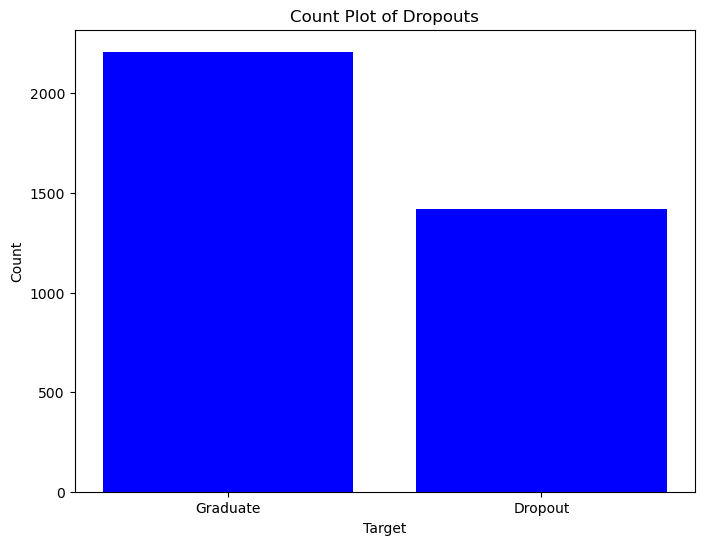

In [9]:
dropout_counts = edu_df['Target'].value_counts()
 
# Using Matplotlib to create a count plot
plt.figure(figsize=(8, 6))
plt.bar(dropout_counts.index, dropout_counts, color='blue')
plt.title('Count Plot of Dropouts')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()